Testing method: auto


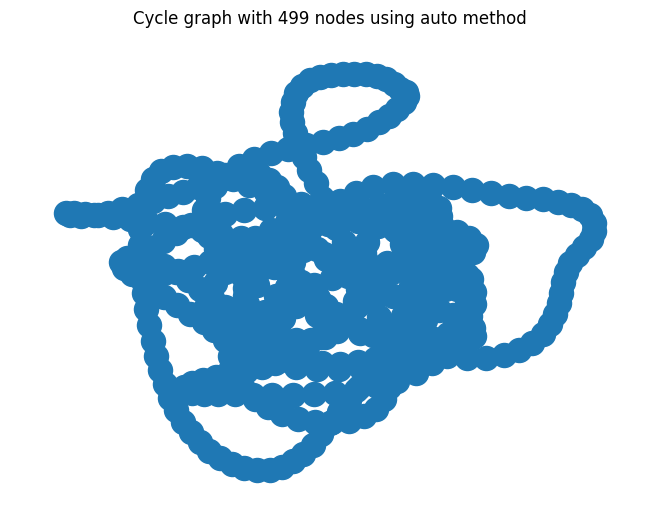

Testing method: energy


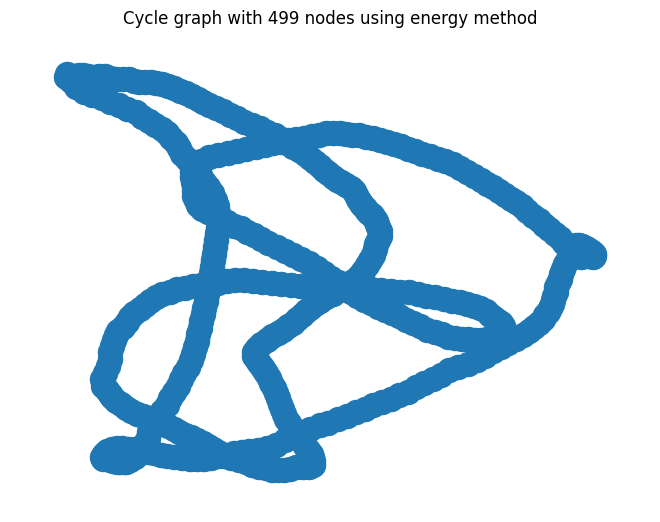

Testing method: force


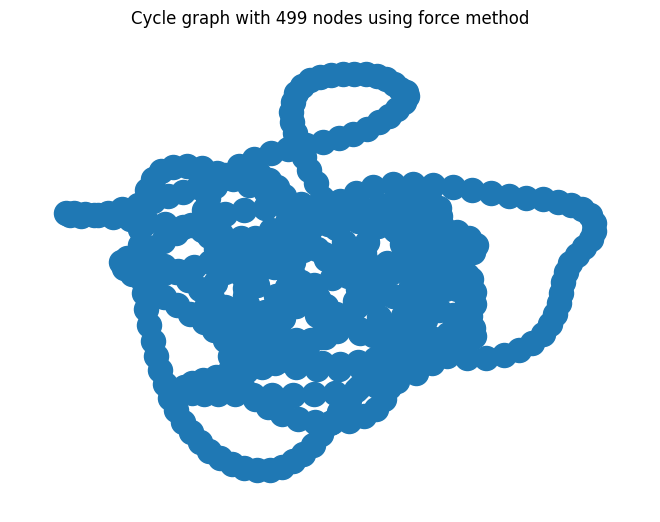

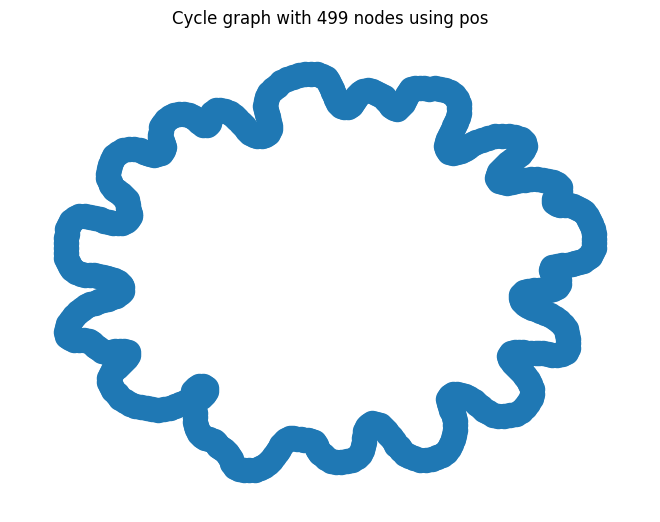

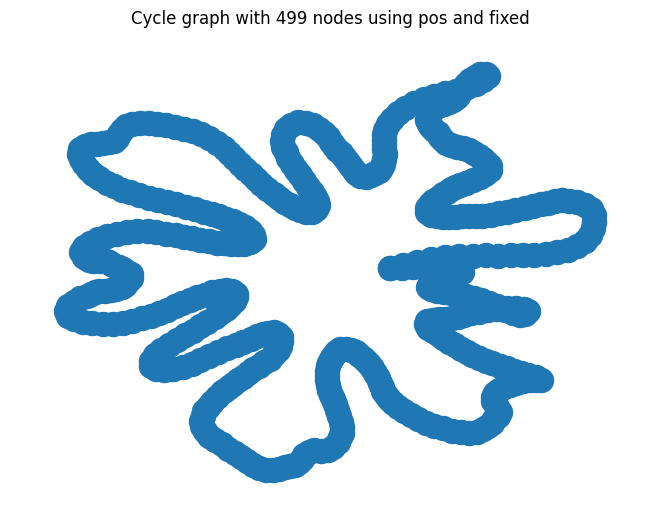

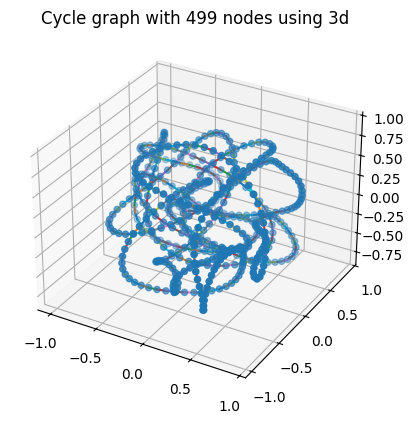

ValueError: negative dimensions are not allowed
Testing method: auto


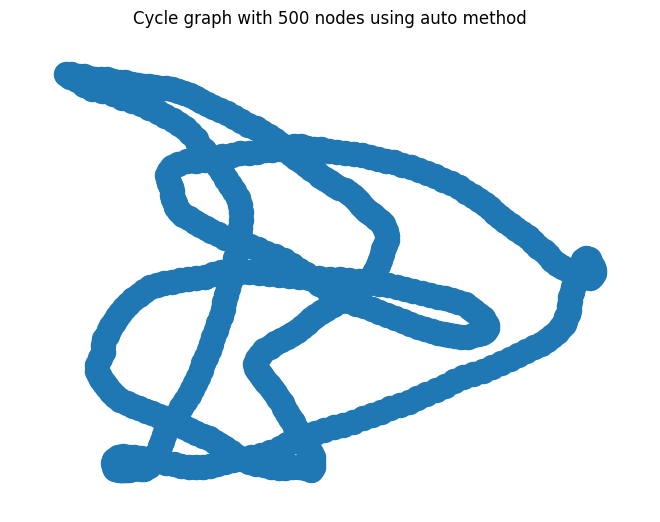

Testing method: energy


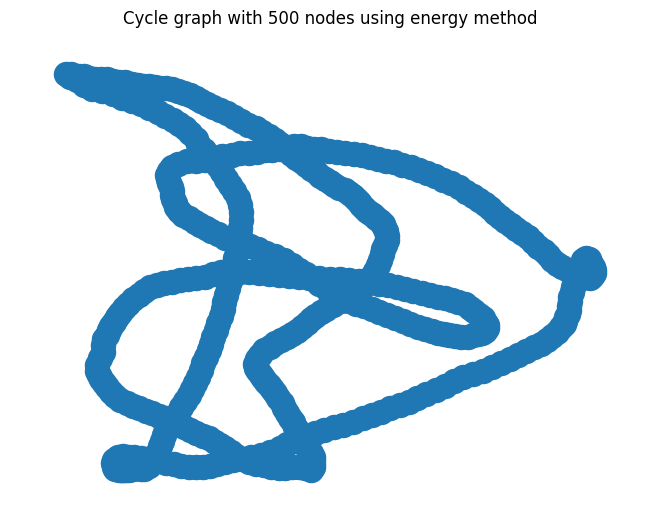

Testing method: force


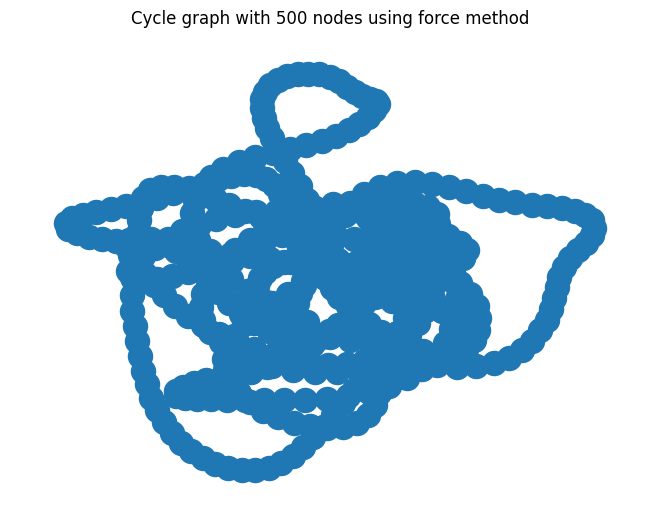

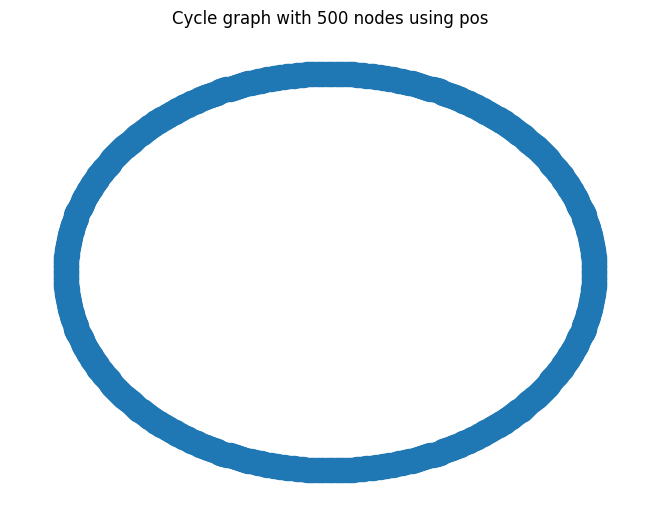

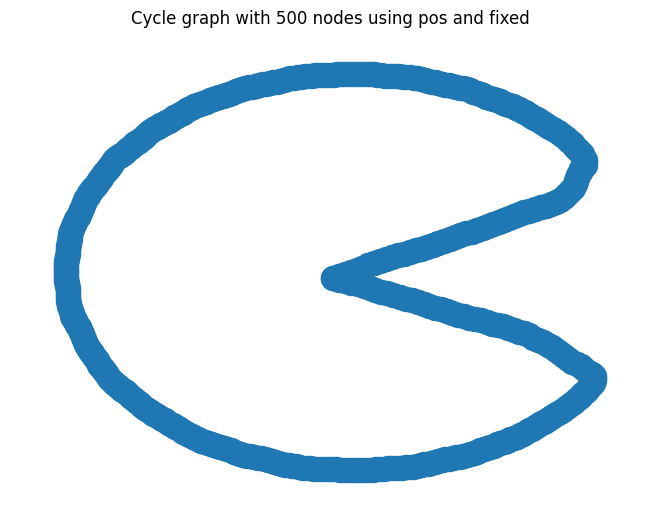

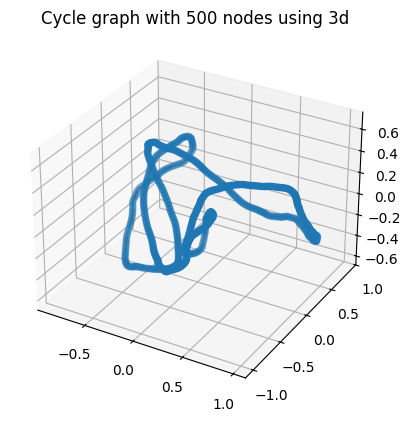

ValueError: negative dimensions are not allowed


In [1]:
import matplotlib.pyplot as plt
import numpy as np

import networkx as nx

np.random.seed(0)

for n in [499, 500]:
    G = nx.cycle_graph(n)

    for method in ["auto", "energy", "force"]:
        print(f"Testing method: {method}")
        pos = nx.spring_layout(G, seed=0, method=method, iterations=100)
        nx.draw(G, pos)
        plt.title(f"Cycle graph with {n} nodes using {method} method")
        plt.show()

    pos = {i: (np.cos(2 * np.pi * i / n), np.sin(2 * np.pi * i / n)) for i in range(n)}

    pos = nx.spring_layout(
        G,
        seed=0,
        method="auto",
        iterations=100,
        pos=pos,
    )
    nx.draw(G, pos)
    plt.title(f"Cycle graph with {n} nodes using pos")
    plt.show()

    pos = nx.spring_layout(
        G,
        seed=0,
        method="auto",
        iterations=100,
        pos=pos,
        fixed=[0, 1],
    )
    nx.draw(G, pos)
    plt.title(f"Cycle graph with {n} nodes using pos and fixed")
    plt.show()

    pos = nx.spring_layout(
        G,
        seed=0,
        method="auto",
        iterations=100,
        dim=3,
    )
    nodes = np.array([pos[v] for v in G])
    edges = np.array([(pos[u], pos[v]) for u, v in G.edges()])
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(nodes[:, 0], nodes[:, 1], nodes[:, 2], marker="o")
    for edge in edges:
        ax.plot(edge[:, 0], edge[:, 1], edge[:, 2])
    ax.set_title(f"Cycle graph with {n} nodes using 3d")
    plt.show()

    try:
        pos = nx.spring_layout(
            G,
            seed=0,
            method="auto",
            iterations=100,
            dim=-1,
            pos=pos,
        )
    except ValueError as e:
        print(f"ValueError: {e}")